# 02 — Modelling the exam score

**Business question.** When a learner joins the platform, can we estimate their expected exam score, and therefore their level (beginner / intermediate / advanced), to adapt the learning path?

**Approach**
- **Target:** `exam_score` (0–100), modelled as a **regression**. The level is derived from the predicted score with the thresholds from `config.py` (50 / 75), so the score and the level shown in the app can never contradict each other.
- **Unit:** one row per student (1,000 students). Feature choices are justified in `01_data_quality_and_eda.ipynb`.
- **Protocol:** 80/20 train/test split stratified on the level → 5-fold cross-validation on the training set to choose the model → one final evaluation on the untouched test set.
- **Primary metric:** MAE, in exam points and easy to explain. RMSE and R² are reported as well, and a mean-prediction baseline sets the floor.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from config import LEARNING_INTERACTIONS_CSV, LEVEL_LABELS, RANDOM_STATE
from ml.data import CATEGORICAL_FEATURES, FEATURES, NUMERIC_FEATURES, load_modeling_data, load_student_performance, score_to_level
from ml.train import CANDIDATES, build_pipeline, compare_models, regression_metrics
from ml.viz import AQUA, BLUE, NEUTRAL, ORANGE, TEXT_MUTED, save, set_style
from matplotlib.colors import LinearSegmentedColormap
from ml.viz import SEQUENTIAL_BLUE

set_style()
pd.set_option("display.precision", 3)

## 1. Why the original 97% accuracy was misleading

The first version of the project:
1. merged the session log (9,000 rows) with the student table, so **each student's target appeared 30 times**;
2. assigned a `topic` to each row by **cycling through a list** (pure noise);
3. used `niveau`, a **binning of the target**, as the "prior level" feature;
4. split rows **at random**, so the same student ended up in both train and test.

Below, the original setup is rebuilt from the raw files and the leaks are removed one at a time (Random Forest classifier, as in the original code).

In [2]:
perf = load_student_performance()
sessions = pd.read_csv(LEARNING_INTERACTIONS_CSV)
topics = ["python", "data preprocessing", "linear regression", "classification", "decision trees", "clustering",
          "dimensionality reduction", "naive bayes", "neural networks", "automl", "statistics", "probability",
          "feature engineering", "model evaluation", "nlp", "transformers"]  # as in the original code
legacy = sessions.merge(perf, on="student_id", suffixes=("", "_perf"))
legacy["topic"] = [topics[i % len(topics)] for i in range(len(legacy))]
legacy["target_level"] = score_to_level(legacy["score_global"])
legacy = legacy.rename(columns={"niveau": "prior_level", "heures_etude_jour": "study_hours", "assignment_score": "practice_tasks",
                                "taux_presence": "attendance", "video_watched_percent": "video_completion"})

def legacy_accuracy(features, split):
    y, groups = legacy["target_level"], legacy["student_id"]
    if split == "random rows":
        train_idx, test_idx = train_test_split(legacy.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    else:
        train_idx, test_idx = next(GroupShuffleSplit(1, test_size=0.2, random_state=RANDOM_STATE).split(legacy, y, groups))
    cat = [f for f in features if f in ("topic", "prior_level")]
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                             ("num", StandardScaler(), [f for f in features if f not in cat])])
    model = make_pipeline(pre, RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    model.fit(legacy.loc[train_idx, features], y[train_idx])
    return (model.predict(legacy.loc[test_idx, features]) == y[test_idx]).mean()

original = ["topic", "prior_level", "study_hours", "practice_tasks", "attendance", "video_completion", "quiz_score"]
no_leak = [f for f in original if f != "prior_level"]
leak_table = pd.DataFrame([
    ("Original: random row split, with prior_level", legacy_accuracy(original, "random rows")),
    ("Split by student, with prior_level", legacy_accuracy(original, "by student")),
    ("Random row split, without prior_level", legacy_accuracy(no_leak, "random rows")),
    ("Split by student, without prior_level", legacy_accuracy(no_leak, "by student")),
    ("Majority-class baseline", legacy["target_level"].value_counts(normalize=True).max()),
], columns=["setup", "test accuracy"])
leak_table

,setup,test accuracy
0,"Original: random row split, with prior_level",0.969
1,"Split by student, with prior_level",0.856
2,"Random row split, without prior_level",0.893
3,"Split by student, without prior_level",0.724
4,Majority-class baseline,0.517


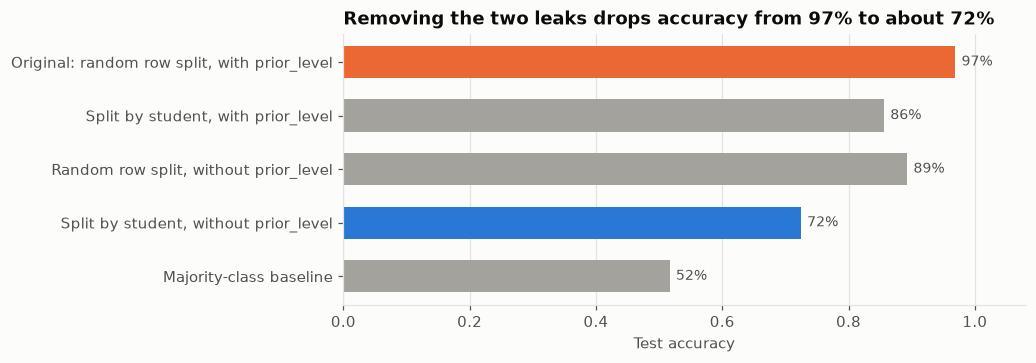

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.2))
colors = [ORANGE, NEUTRAL, NEUTRAL, BLUE, NEUTRAL]
ax.barh(leak_table["setup"][::-1], leak_table["test accuracy"][::-1], color=colors[::-1], height=0.6)
for y, v in enumerate(leak_table["test accuracy"][::-1]):
    ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=9, color=TEXT_MUTED)
ax.set_xlim(0, 1.08)
ax.set_xlabel("Test accuracy")
ax.set_title("Removing the two leaks drops accuracy from 97% to about 72%")
ax.grid(axis="y", visible=False)
save(fig, "leakage_effect")
plt.show()

**Takeaway.** Most of the headline accuracy came from leakage: target information (`prior_level`) and the same students in train and test. Once both are fixed, this setup reaches roughly 72%, and the part of that signal coming from the session log is no better than chance (see notebook 01). The rest of this notebook builds the model the correct way, **on the student table only**.

## 2. Train / test split

In [4]:
X, y = load_modeling_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=score_to_level(y))
print(f"train: {X_train.shape}, test: {X_test.shape}")
pd.DataFrame({"train": score_to_level(y_train).value_counts(normalize=True),
              "test": score_to_level(y_test).value_counts(normalize=True)}).reindex(LEVEL_LABELS)

train: (800, 11), test: (200, 11)


,train,test
exam_score,,
beginner,0.070,0.070
intermediate,0.527,0.525
advanced,0.403,0.405


Preprocessing (median imputation, scaling, one-hot encoding) lives **inside** the scikit-learn `Pipeline`, so it is fitted on the training folds only. No statistics from validation or test data leak into training.

## 3. Model comparison (5-fold cross-validation on the training set)

In [5]:
leaderboard = compare_models(X_train, y_train)
leaderboard

,model,cv_mae,cv_mae_std,cv_rmse,cv_r2
0,Ridge,4.044,0.394,5.032,0.878
1,Random Forest,4.341,0.227,5.476,0.856
2,Gradient Boosting,4.532,0.203,5.697,0.844
3,Baseline (mean),12.229,0.514,14.511,-0.003


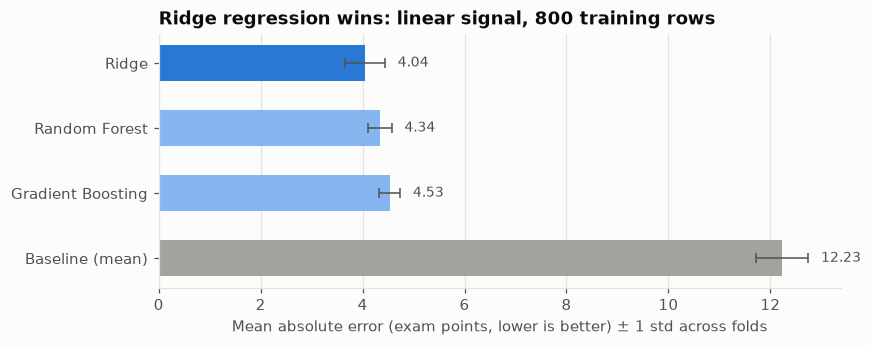

In [6]:
lb = leaderboard.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 3))
colors = [NEUTRAL if m.startswith("Baseline") else (BLUE if i == len(lb) - 1 else "#86b6ef") for i, m in enumerate(lb["model"])]
ax.barh(lb["model"], lb["cv_mae"], xerr=lb["cv_mae_std"], color=colors, height=0.55,
        error_kw={"ecolor": TEXT_MUTED, "elinewidth": 1, "capsize": 3})
for yy, (v, s) in enumerate(zip(lb["cv_mae"], lb["cv_mae_std"])):
    ax.text(v + s + 0.25, yy, f"{v:.2f}", va="center", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Mean absolute error (exam points, lower is better) ± 1 std across folds")
ax.set_title("Ridge regression wins: linear signal, 800 training rows")
ax.grid(axis="y", visible=False)
save(fig, "cv_leaderboard")
plt.show()

All models cut the baseline error by about two thirds. **Ridge** is the best and the simplest, and it's interpretable. The tree ensembles don't beat it, which suggests the relationships are essentially linear (consistent with the EDA scatter plots). No hyperparameter search was run: with a clear winner and this little data, tuning would mostly fit noise in the validation folds.

## 4. Final evaluation on the held-out test set

In [7]:
best_name = leaderboard.loc[~leaderboard["model"].str.startswith("Baseline"), "model"].iloc[0]
model = build_pipeline(CANDIDATES[best_name]).fit(X_train, y_train)
y_pred = np.clip(model.predict(X_test), 0, 100)

pd.DataFrame({
    best_name: regression_metrics(y_test, y_pred),
    "Baseline (train mean)": regression_metrics(y_test, np.full(len(y_test), y_train.mean())),
}).T

,mae,rmse,r2
Ridge,4.537,5.588,0.835
Baseline (train mean),11.357,13.805,-0.009


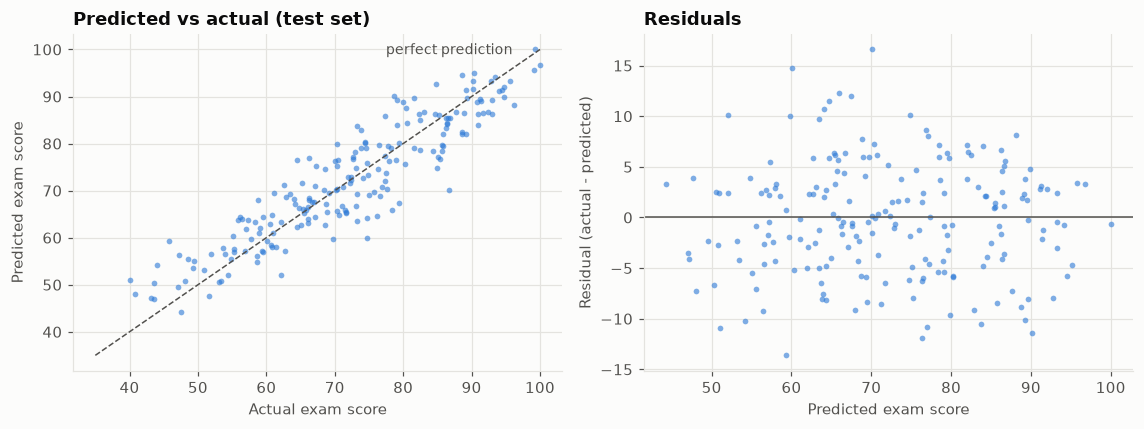

Share of students predicted within ±5 points: 61%


In [8]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
ax = axes[0]
ax.scatter(y_test, y_pred, s=14, alpha=0.6, color=BLUE, linewidths=0)
ax.plot([35, 100], [35, 100], color=TEXT_MUTED, linestyle="--", linewidth=1)
ax.text(96, 99, "perfect prediction", ha="right", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("Actual exam score")
ax.set_ylabel("Predicted exam score")
ax.set_title("Predicted vs actual (test set)")

ax = axes[1]
ax.scatter(y_pred, residuals, s=14, alpha=0.6, color=BLUE, linewidths=0)
ax.axhline(0, color=TEXT_MUTED, linewidth=1)
ax.set_xlabel("Predicted exam score")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals")
plt.tight_layout()
save(fig, "test_predictions")
plt.show()

print(f"Share of students predicted within ±5 points: {(residuals.abs() <= 5).mean():.0%}")

- On unseen students the model is off by **about 4.5 points on average** (R² ≈ 0.84), versus about 11 points for the baseline.
- The residuals are centred on zero with no visible trend or funnel shape across the score range, so there's no sign of a systematic bias the linear model misses.

### 4.1 Derived level: how often is the learner placed in the right group?

In [9]:
true_level, pred_level = score_to_level(y_test), score_to_level(pd.Series(y_pred, index=y_test.index))
print(classification_report(true_level, pred_level, labels=LEVEL_LABELS, digits=2, zero_division=0))

              precision    recall  f1-score   support

    beginner       0.83      0.36      0.50        14
intermediate       0.80      0.83      0.81       105
    advanced       0.80      0.84      0.82        81

    accuracy                           0.80       200
   macro avg       0.81      0.68      0.71       200
weighted avg       0.80      0.80      0.79       200



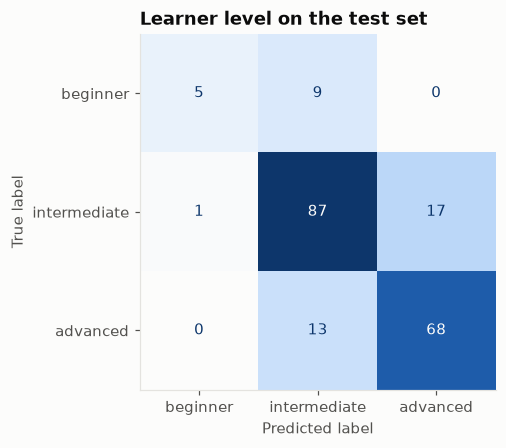

In [10]:
cmap = LinearSegmentedColormap.from_list("seq_blue", ["#fcfcfb"] + SEQUENTIAL_BLUE)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay.from_predictions(true_level, pred_level, labels=LEVEL_LABELS, cmap=cmap, colorbar=False, ax=ax)
ax.grid(False)
ax.set_title("Learner level on the test set")
save(fig, "level_confusion_matrix")
plt.show()

- Every error is between **adjacent** levels (never beginner ↔ advanced).
- **Weakest point: beginners** (the rare 7% class). Their scores sit just below the 50 threshold, so a prediction error of a few points is enough to move them to "intermediate". In the app this is a soft error, because the student still gets the intermediate path and the quiz results keep updating the plan. If spotting struggling students were the business priority, next steps would be a dedicated classifier with class weights, or a lower decision threshold tuned for beginner recall.

## 5. What drives the prediction?

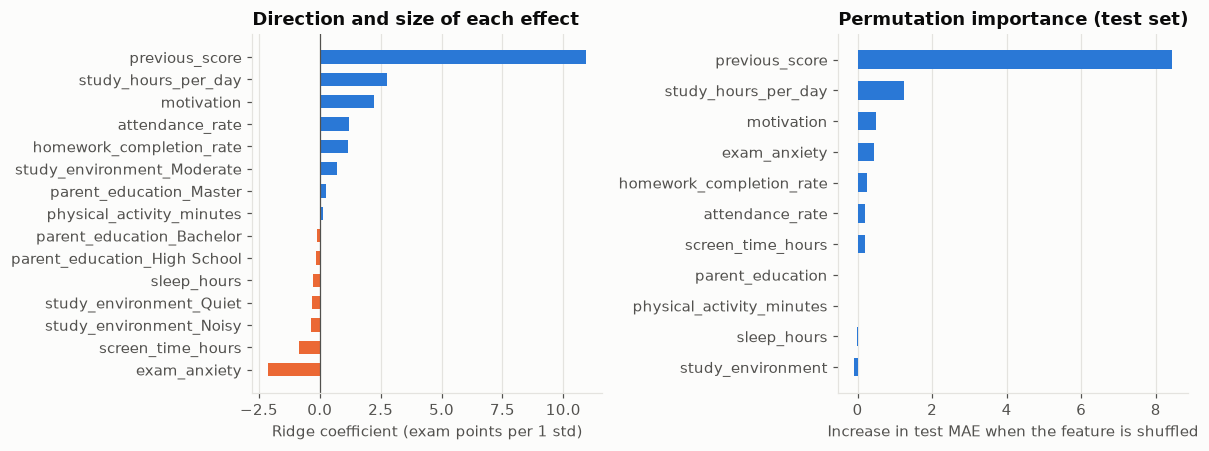

,exam_anxiety,screen_time_hours,study_environment_Noisy,study_environment_Quiet,sleep_hours,parent_education_High School,parent_education_Bachelor,physical_activity_minutes,parent_education_Master,study_environment_Moderate,homework_completion_rate,attendance_rate,motivation,study_hours_per_day,previous_score
coefficient,-2.12,-0.85,-0.37,-0.32,-0.3,-0.15,-0.12,0.12,0.27,0.69,1.17,1.18,2.24,2.76,10.94


In [11]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(model.named_steps["model"].coef_, index=[n.split("__", 1)[1] for n in feature_names]).sort_values()

perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.barh(coefs.index, coefs.values, color=[BLUE if v >= 0 else ORANGE for v in coefs], height=0.6)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.8)
ax.set_xlabel("Ridge coefficient (exam points per 1 std)")
ax.set_title("Direction and size of each effect")
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.barh(importance.index, importance.values, color=BLUE, height=0.6)
ax.set_xlabel("Increase in test MAE when the feature is shuffled")
ax.set_title("Permutation importance (test set)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save(fig, "feature_importance")
plt.show()
coefs.round(2).to_frame("coefficient").T

- **Previous score dominates**: shuffling it raises the test error by about 8 points. Study time and motivation come next, and **exam anxiety** lowers the expected score.
- **Attendance** correlates strongly with the exam score (r = 0.74) but adds little here, because it is itself highly correlated with previous score (r = 0.85). The model gets that information from `previous_score` already. Correlated features share credit, so a low importance doesn't mean "irrelevant".
- Sleep, physical activity, parental education and study environment contribute close to nothing, which matches the EDA.
- These coefficients describe associations in the training data. They **don't show** that changing a habit would change a student's score.

## 6. How the web app uses the model

In the app, a new learner has only answered a short quiz. `ml/model.py` therefore makes a **cold-start assumption**: the quiz score stands in for `previous_score`, and every other feature takes the median or most frequent value from the training data.

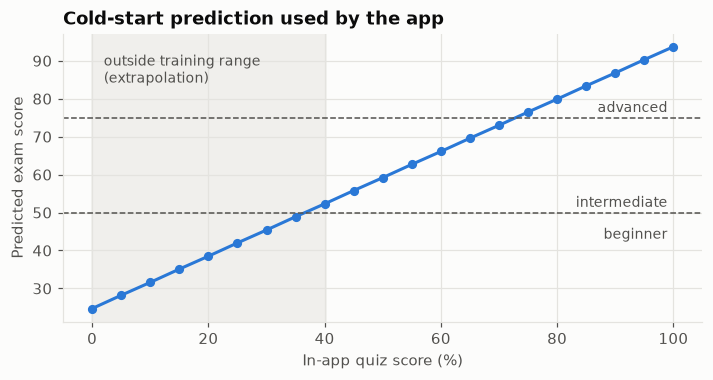

In [12]:
from ml.model import ExamScoreModel

app_model = ExamScoreModel.load()
quiz_scores = np.arange(0, 101, 5)
predicted = [app_model.predict_from_quiz(q)[0] for q in quiz_scores]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.axvspan(0, X["previous_score"].min(), color="#f0efec", zorder=0)
ax.text(2, 92, "outside training range\n(extrapolation)", fontsize=9, color=TEXT_MUTED, va="top")
ax.plot(quiz_scores, predicted, color=BLUE, marker="o", markersize=5)
for t in (50, 75):
    ax.axhline(t, color=TEXT_MUTED, linestyle="--", linewidth=1)
ax.text(99, 76.5, "advanced", ha="right", fontsize=9, color=TEXT_MUTED)
ax.text(99, 51.5, "intermediate", ha="right", fontsize=9, color=TEXT_MUTED)
ax.text(99, 46, "beginner", ha="right", va="top", fontsize=9, color=TEXT_MUTED)
ax.set_xlabel("In-app quiz score (%)")
ax.set_ylabel("Predicted exam score")
ax.set_title("Cold-start prediction used by the app")
save(fig, "app_cold_start")
plt.show()

The mapping is monotonic and bounded. Below 40%, `previous_score` values were never seen in training, so those predictions are extrapolated and should be read as "clearly beginner", not as precise numbers. The natural improvement is to ask learners a few questions at sign-up (study hours, attendance…) so the model gets real inputs instead of medians.

## 7. Conclusions & limitations

| | |
|---|---|
| **Model** | Ridge regression, one pipeline (impute → scale / one-hot → Ridge), saved by `python -m ml.train` |
| **Performance (test)** | MAE ≈ 4.5 points, R² ≈ 0.84, baseline MAE ≈ 11.4 |
| **Level** | 80% accuracy, macro-F1 ≈ 0.71; errors only between adjacent levels; weak recall on the rare beginner class |
| **Main drivers** | Previous score (dominant), study time, motivation (+), exam anxiety (−) |

**Limitations**
- The data appears **synthetic**, so these scores measure how well the model recovers the simulation, not real-world performance.
- 1,000 students, one cohort, no time dimension: no evidence the model would generalise to another school or year.
- In the app, most features are imputed (cold start), so real predictions there are less accurate than the test metrics.
- Correlational analysis only: no causal claims.

**Next steps:** collect real learner features at sign-up, monitor prediction error on real outcomes, and try a class-weighted classifier if detecting beginners matters more than score accuracy.